# MelCNN-MGR EDA and Data Understanding

This notebook audits the manifest pipeline defined by `1_build_all_datasets_and_samples.py`. It is focused on data understanding, not model training.

Pipeline boundary studied here:

1. file-level discovery and audit
2. segment-level expansion
3. final train/validation/test selection

Core artifacts loaded by this notebook:

- `manifest_all_datasets.parquet`
- `manifest_all_samples.parquet`
- `manifest_final_samples.parquet`
- `settings.json`

## Notebook Map

This notebook follows a manifest-centric EDA flow:

1. configuration and path setup
2. manifest loading and schema inspection
3. file-level composition and imbalance
4. skip logic and reason-code analysis
5. duration analysis
6. duration grouping and notebook-side yield metrics
7. actual emitted sample-row analysis
8. final split analysis
9. leakage-safety validation
10. class-balance evolution across stages
11. key findings and readiness summary

In [1]:
from __future__ import annotations



import importlib

import json

import re

from pathlib import Path



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import Markdown, display



sns = None

if importlib.util.find_spec("seaborn") is not None:

    sns = importlib.import_module("seaborn")

    sns.set_theme(style="whitegrid")

HAS_SEABORN = sns is not None



pd.set_option("display.max_columns", 200)

pd.set_option("display.width", 140)

pd.set_option("display.max_colwidth", 120)



NOTEBOOK_NAME = "MelCNN_MGR_EDA_and_Data_Understanding"

print(f"Loaded notebook helpers for {NOTEBOOK_NAME}")

print(f"Seaborn available: {HAS_SEABORN}")


Loaded notebook helpers for MelCNN_MGR_EDA_and_Data_Understanding
Seaborn available: True


In [ ]:
def resolve_project_paths(start: Path) -> tuple[Path, Path]:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / "MelCNN-MGR" / "settings.json").exists():
            return candidate, candidate / "MelCNN-MGR"
        if candidate.name == "MelCNN-MGR" and (candidate / "settings.json").exists():
            return candidate.parent, candidate
    raise FileNotFoundError("Could not locate workspace root containing MelCNN-MGR/settings.json")

WORKSPACE_ROOT, MELCNN_DIR = resolve_project_paths(Path.cwd())
PROCESSED_DIR = MELCNN_DIR / "data" / "processed"
SETTINGS_PATH = MELCNN_DIR / "settings.json"
ALL_DATASETS_PATH = PROCESSED_DIR / "manifest_all_datasets.parquet"
ALL_SAMPLES_PATH = PROCESSED_DIR / "manifest_all_samples.parquet"
FINAL_SAMPLES_PATH = PROCESSED_DIR / "manifest_final_samples.parquet"
OUTPUT_DIR = MELCNN_DIR / "notebooks" / "outputs" / NOTEBOOK_NAME
SAVE_FIGURES = False

with SETTINGS_PATH.open("r", encoding="utf-8") as fh:
    settings_payload = json.load(fh)

sampling_settings = settings_payload.get("data_sampling_settings", {})
sample_length_sec = float(sampling_settings["sample_length_sec"])
target_genres = sampling_settings["target_genres"]

config_rows = [
    {"key": "workspace_root", "value": str(WORKSPACE_ROOT)},
    {"key": "melcnn_dir", "value": str(MELCNN_DIR)},
    {"key": "processed_dir", "value": str(PROCESSED_DIR)},
    {"key": "manifest_all_datasets", "value": str(ALL_DATASETS_PATH)},
    {"key": "manifest_all_samples", "value": str(ALL_SAMPLES_PATH)},
    {"key": "manifest_final_samples", "value": str(FINAL_SAMPLES_PATH)},
    {"key": "save_figures", "value": SAVE_FIGURES},
    {"key": "output_dir", "value": str(OUTPUT_DIR)},
    {"key": "target_genres", "value": ", ".join(target_genres)},
    {"key": "sample_length_sec", "value": sample_length_sec},
    {"key": "min_duration_delta", "value": sampling_settings.get("min_duration_delta")},
    {"key": "number_of_samples_expected_each_genre", "value": sampling_settings.get("number_of_samples_expected_each_genre")},
    {
        "key": "additional_samples_contribution_ratio_expected_each_genre",
        "value": sampling_settings.get("additional_samples_contribution_ratio_expected_each_genre"),
    },
    {"key": "train_n_val_test_split_ratio_each_genre", "value": sampling_settings.get("train_n_val_test_split_ratio_each_genre")},
]

display(Markdown("## Configuration and Path Setup"))
display(pd.DataFrame(config_rows))

## Configuration and Path Setup

,key,value
0,workspace_root,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1
1,melcnn_dir,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR
2,processed_dir,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed
3,manifest_all_datasets,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_all_datasets.parquet
4,manifest_all_samples,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_all_samples.parquet
5,manifest_final_samples,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_final_samples.parquet
6,save_figures,False
7,output_dir,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/model_training/outputs/MelCNN_MGR_EDA_and_Data_Understa...
8,target_genres,"Hip-Hop, Pop, Folk, Rock, Electronic, Classical, Jazz, Country, Blues"
9,sample_length_sec,10.0


In [10]:
def maybe_savefig(name: str) -> None:
    if not SAVE_FIGURES:
        return
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    path = OUTPUT_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {path}")


def display_frame_overview(name: str, frame: pd.DataFrame, head_rows: int = 5) -> None:
    display(Markdown(f"### {name}"))
    print(f"shape = {frame.shape}")
    display(frame.head(head_rows))
    dtype_frame = pd.DataFrame({
        "column": frame.columns,
        "dtype": [str(dtype) for dtype in frame.dtypes],
        "null_count": frame.isna().sum().values,
        "null_pct": (frame.isna().mean() * 100).round(2).values,
    })
    display(dtype_frame)


def imbalance_table(series: pd.Series) -> pd.DataFrame:
    counts = series.value_counts(dropna=False)
    if counts.empty:
        return pd.DataFrame(columns=["count", "proportion_pct", "imbalance_ratio_vs_max"])
    table = counts.rename_axis(series.name or "category").reset_index(name="count")
    table["proportion_pct"] = (table["count"] / table["count"].sum() * 100).round(2)
    table["imbalance_ratio_vs_max"] = (table["count"].max() / table["count"]).round(3)
    return table


def plot_bar(series: pd.Series, title: str, xlabel: str = "", ylabel: str = "count", rotation: int = 45, figsize: tuple[int, int] = (10, 5), color: str = "#4C78A8") -> None:
    data = series.sort_values(ascending=False)
    _, ax = plt.subplots(figsize=figsize)
    data.plot(kind="bar", ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)
    maybe_savefig(re.sub(r"[^A-Za-z0-9_]+", "_", title.lower()).strip("_"))
    plt.show()


def plot_hist(series: pd.Series, title: str, bins: int = 40, figsize: tuple[int, int] = (10, 5), color: str = "#72B7B2") -> None:
    clean = pd.to_numeric(series, errors="coerce").dropna()
    _, ax = plt.subplots(figsize=figsize)
    ax.hist(clean, bins=bins, color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(series.name or "value")
    ax.set_ylabel("count")
    maybe_savefig(re.sub(r"[^A-Za-z0-9_]+", "_", title.lower()).strip("_"))
    plt.show()


def plot_box(frame: pd.DataFrame, value_col: str, category_col: str, title: str, figsize: tuple[int, int] = (12, 5)) -> None:
    clean = frame[[category_col, value_col]].dropna().copy()
    if clean.empty:
        print(f"No data available for {title}")
        return
    ordered_categories = clean.groupby(category_col)[value_col].median().sort_values(ascending=False).index
    _, ax = plt.subplots(figsize=figsize)
    if HAS_SEABORN:
        sns.boxplot(data=clean, x=category_col, y=value_col, order=ordered_categories, ax=ax)
    else:
        clean.boxplot(column=value_col, by=category_col, ax=ax, grid=False)
        plt.suptitle("")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    maybe_savefig(re.sub(r"[^A-Za-z0-9_]+", "_", title.lower()).strip("_"))
    plt.show()


def plot_heatmap(table: pd.DataFrame, title: str, figsize: tuple[int, int] = (10, 6), fmt: str = ".0f") -> None:
    numeric_table = table.apply(pd.to_numeric, errors="coerce")
    if numeric_table.isna().all(axis=None):
        print(f"No numeric data available for {title}")
        return

    _, ax = plt.subplots(figsize=figsize)

    if HAS_SEABORN:
        sns.heatmap(numeric_table, annot=True, fmt=fmt, cmap="YlGnBu", ax=ax)
    else:
        im = ax.imshow(numeric_table.values, aspect="auto", cmap="YlGnBu")
        ax.set_xticks(np.arange(numeric_table.shape[1]))
        ax.set_yticks(np.arange(numeric_table.shape[0]))
        ax.set_xticklabels(numeric_table.columns)
        ax.set_yticklabels(numeric_table.index)
        for i in range(numeric_table.shape[0]):
            for j in range(numeric_table.shape[1]):
                value = numeric_table.values[i, j]
                label = "" if pd.isna(value) else format(value, fmt)
                ax.text(j, i, label, ha="center", va="center", color="black")
        plt.colorbar(im, ax=ax)

    ax.set_title(title)
    maybe_savefig(re.sub(r"[^A-Za-z0-9_]+", "_", title.lower()).strip("_"))
    plt.show()


def artifact_id_from_sample_id(sample_id: str) -> str:
    return re.sub(r":seg\d+$", "", str(sample_id))


def maybe_duration_kmeans(values: pd.Series, n_clusters: int = 4) -> tuple[pd.Series | None, pd.DataFrame | None]:
    clean = pd.to_numeric(values, errors="coerce").dropna()
    if clean.empty:
        return None, None
    try:
        from sklearn.cluster import KMeans
    except ImportError:
        return None, None

    effective_clusters = min(n_clusters, clean.nunique(), len(clean))
    if effective_clusters < 2:
        return None, None

    model = KMeans(n_clusters=effective_clusters, random_state=42, n_init=10)
    labels = model.fit_predict(clean.to_numpy().reshape(-1, 1))
    centers = model.cluster_centers_.ravel()

    label_series = pd.Series(index=clean.index, data=labels, dtype="Int64")
    ordering = pd.Series(centers).sort_values().index.tolist()
    relabel_map = {old_label: new_label for new_label, old_label in enumerate(ordering, start=1)}
    label_series = label_series.map(relabel_map).astype("Int64")

    center_table = pd.DataFrame({
        "cluster": [relabel_map[idx] for idx in range(len(centers))],
        "center_duration_s": centers,
    }).sort_values("cluster").reset_index(drop=True)
    return label_series, center_table

In [4]:
all_datasets_df = pd.read_parquet(ALL_DATASETS_PATH)
all_samples_df = pd.read_parquet(ALL_SAMPLES_PATH)
final_samples_df = pd.read_parquet(FINAL_SAMPLES_PATH)

manifest_shapes = pd.DataFrame([
    {"manifest": "manifest_all_datasets", "rows": len(all_datasets_df), "columns": all_datasets_df.shape[1]},
    {"manifest": "manifest_all_samples", "rows": len(all_samples_df), "columns": all_samples_df.shape[1]},
    {"manifest": "manifest_final_samples", "rows": len(final_samples_df), "columns": final_samples_df.shape[1]},
])

display(Markdown("## Load and Inspect Manifests"))
display(manifest_shapes)

## Load and Inspect Manifests

,manifest,rows,columns
0,manifest_all_datasets,16355,15
1,manifest_all_samples,46868,13
2,manifest_final_samples,10481,14


In [5]:
display_frame_overview("manifest_all_datasets", all_datasets_df)
display_frame_overview("manifest_all_samples", all_samples_df)
display_frame_overview("manifest_final_samples", final_samples_df)

### manifest_all_datasets

shape = (16355, 15)


,source,artifact_id,source_track_id,track_id,genre_top,filepath,audio_exists,filesize_bytes,actual_duration_s,duration_s,reason_code,sampling_eligible,sampling_num_segments,sampling_exclusion_reason,manifest_origin
0,dortmund-university,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/All_Men_Are_Dogs_-GIGOLETTE.mp3,NaN,<NA>,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/All_Men_Ar...,True,160914,10.057125,11.0,OK,True,1,NaN,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university
1,dortmund-university,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/All_Men_Are_Dogs_-I_M_LOOKING_FOR_MY_HU...,NaN,<NA>,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/All_Men_Ar...,True,160914,10.057125,11.0,OK,True,1,NaN,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university
2,dortmund-university,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Andy_Kimbel-Red_Hot_Blues.mp3,NaN,<NA>,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Andy_Kimbe...,True,160914,10.057125,11.0,OK,True,1,NaN,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university
3,dortmund-university,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/BB_CHUNG_KING_AND_THE_BUDDAHEADS-COMPAN...,NaN,<NA>,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/BB_CHUNG_K...,True,160914,10.057125,11.0,OK,True,1,NaN,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university
4,dortmund-university,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/BB_CHUNG_KING_AND_THE_BUDDAHEADS-LITTLE...,NaN,<NA>,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/BB_CHUNG_K...,True,160914,10.057125,11.0,OK,True,1,NaN,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university


,column,dtype,null_count,null_pct
0,source,str,0,0.00
1,artifact_id,str,0,0.00
2,source_track_id,str,1777,10.87
3,track_id,Int64,1777,10.87
4,genre_top,str,0,0.00
5,filepath,str,0,0.00
6,audio_exists,bool,0,0.00
7,filesize_bytes,Int64,0,0.00
8,actual_duration_s,float64,12,0.07
9,duration_s,float64,12,0.07


### manifest_all_samples

...

,column,dtype,null_count,null_pct
0,sample_id,str,0,0.00
1,source,str,0,0.00
2,genre_top,str,0,0.00
3,filepath,str,0,0.00
4,track_id,Int64,3174,6.77
5,sample_length_sec,float64,0,0.00
6,segment_index,int64,0,0.00
7,segment_start_sec,float64,0,0.00
8,segment_end_sec,float64,0,0.00
9,total_segments_from_audio,Int64,0,0.00


### manifest_final_samples

shape = (10481, 14)


,sample_id,source,genre_top,filepath,track_id,sample_length_sec,segment_index,segment_start_sec,segment_end_sec,total_segments_from_audio,duration_s,actual_duration_s,reason_code,final_split
0,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Chumslick_Nick_and_the_Sharks-Married_t...,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Chumslick_...,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test
1,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Suspects-Wonderful_Terrible_Thing.mp3:s...,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Suspects-W...,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test
2,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Ted_McCloskey-let_me_go_or_let_me_in.mp...,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Ted_McClos...,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test
3,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/The_Griswolds-The_Later_It_GEts__The_Be...,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/The_Griswo...,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test
4,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/The__Dare_Ya_Blues_Band-Waisted_on_Club...,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/The__Dare_...,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test


,column,dtype,null_count,null_pct
0,sample_id,str,0,0.00
1,source,str,0,0.00
2,genre_top,str,0,0.00
3,filepath,str,0,0.00
4,track_id,Int64,2213,21.11
5,sample_length_sec,float64,0,0.00
6,segment_index,int64,0,0.00
7,segment_start_sec,float64,0,0.00
8,segment_end_sec,float64,0,0.00
9,total_segments_from_audio,Int64,0,0.00


## File-Level Dataset Composition

This section uses `manifest_all_datasets.parquet` to answer:

- how many audio candidates were discovered
- which sources contribute most rows
- how genre distribution looks before segment expansion
- how large the class imbalance is

,metric,value
0,total_discovered_audio_candidates,16355
1,usable_reason_code_OK,16341
2,sampling_eligible_true,16341
3,unique_sources,3
4,unique_genres,9


### Counts by Source

,source,count
0,fma-medium,14578
1,dortmund-university,1077
2,gtzan,700


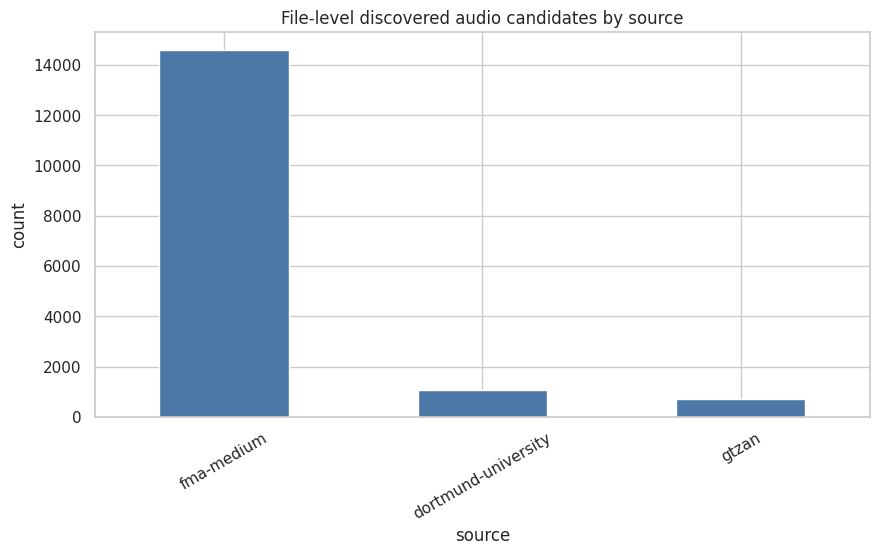

### Counts by Genre

,genre_top,count,proportion_pct,imbalance_ratio_vs_max
0,Rock,6203,37.93,1.000
1,Electronic,5314,32.49,1.167
2,Hip-Hop,1601,9.79,3.874
3,Jazz,803,4.91,7.725
4,Classical,719,4.40,8.627
5,Folk,519,3.17,11.952
6,Country,500,3.06,12.406
7,Pop,402,2.46,15.430
8,Blues,294,1.80,21.099


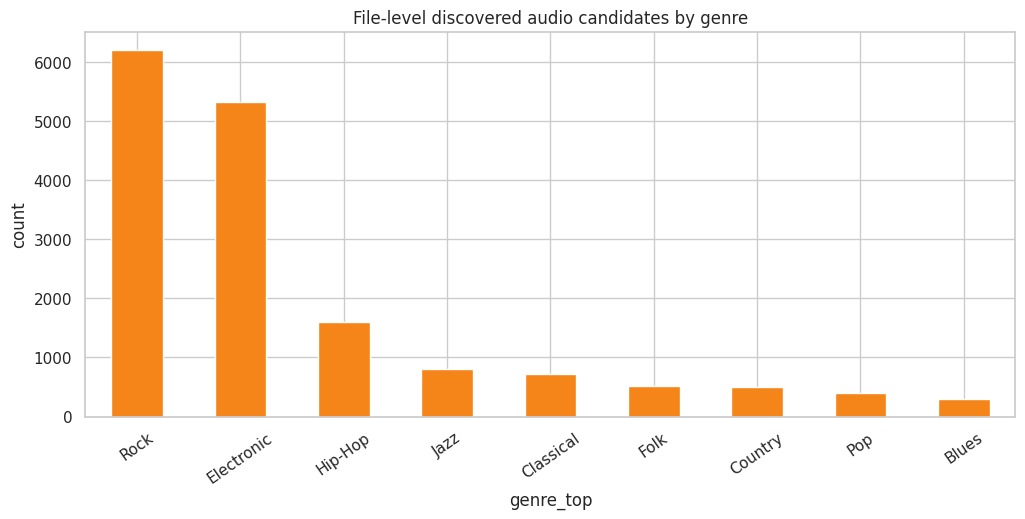

### Counts by Reason Code and Sampling Eligibility

,reason_code,count
0,OK,16341
1,AUDIO_READ_FAILED,12
2,TOO_SHORT,2


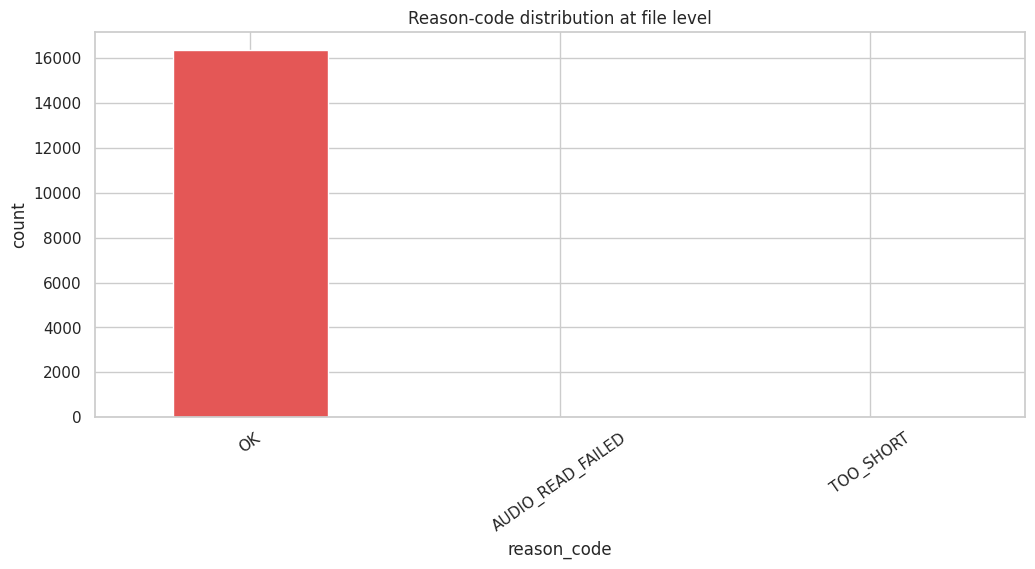

,sampling_eligible,count
0,True,16341
1,False,14


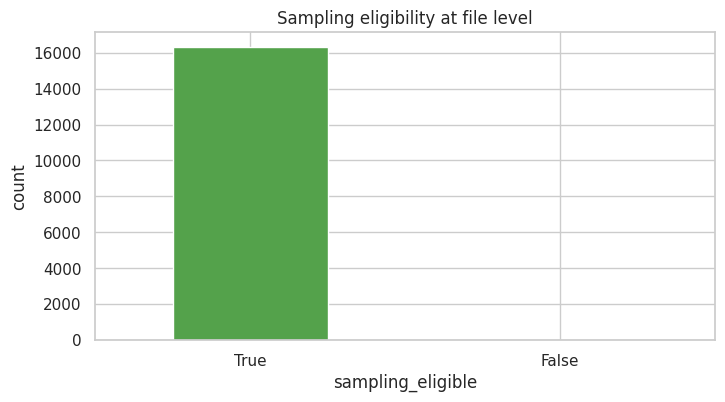

In [6]:
file_level_summary = pd.DataFrame([
    {"metric": "total_discovered_audio_candidates", "value": len(all_datasets_df)},
    {"metric": "usable_reason_code_OK", "value": int((all_datasets_df['reason_code'] == 'OK').sum())},
    {"metric": "sampling_eligible_true", "value": int(all_datasets_df['sampling_eligible'].fillna(False).sum())},
    {"metric": "unique_sources", "value": all_datasets_df['source'].nunique(dropna=True)},
    {"metric": "unique_genres", "value": all_datasets_df['genre_top'].nunique(dropna=True)},
])

display(file_level_summary)
display(Markdown("### Counts by Source"))
source_counts = all_datasets_df['source'].value_counts()
display(source_counts.rename_axis('source').reset_index(name='count'))
plot_bar(source_counts, title='File-level discovered audio candidates by source', xlabel='source', rotation=30)

display(Markdown("### Counts by Genre"))
genre_counts = all_datasets_df['genre_top'].value_counts()
display(imbalance_table(all_datasets_df['genre_top']))
plot_bar(genre_counts, title='File-level discovered audio candidates by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#F58518')

display(Markdown("### Counts by Reason Code and Sampling Eligibility"))
reason_counts = all_datasets_df['reason_code'].value_counts()
display(reason_counts.rename_axis('reason_code').reset_index(name='count'))
plot_bar(reason_counts, title='Reason-code distribution at file level', xlabel='reason_code', rotation=35, figsize=(12, 5), color='#E45756')

eligibility_counts = all_datasets_df['sampling_eligible'].astype(str).value_counts()
display(eligibility_counts.rename_axis('sampling_eligible').reset_index(name='count'))
plot_bar(eligibility_counts, title='Sampling eligibility at file level', xlabel='sampling_eligible', rotation=0, figsize=(8, 4), color='#54A24B')

## Skip Logic and Duration Analysis

This section audits what was skipped and why, then studies the duration fields that drive fixed-length segment generation.

Important distinction:

- `actual_duration_s`: measured duration from the audio probe
- `duration_s`: normalized duration used by the manifest builder for sampling decisions

### Skipped Files by Source and Reason Code

reason_code,AUDIO_READ_FAILED,OK,TOO_SHORT
source,,,
dortmund-university,0,1077,0
fma-medium,11,14565,2
gtzan,1,699,0


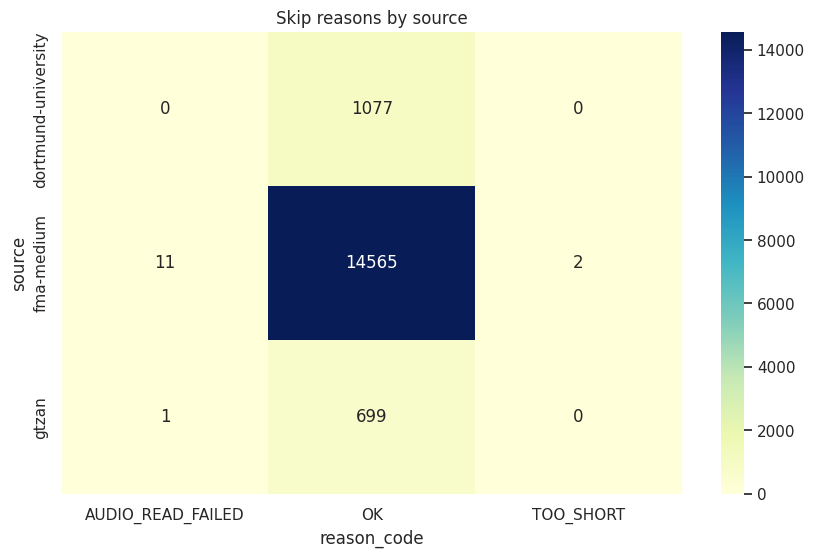

### sampling_exclusion_reason

,sampling_exclusion_reason,count
0,NONE,16341
1,AUDIO_READ_FAILED,12
2,TOO_SHORT,2


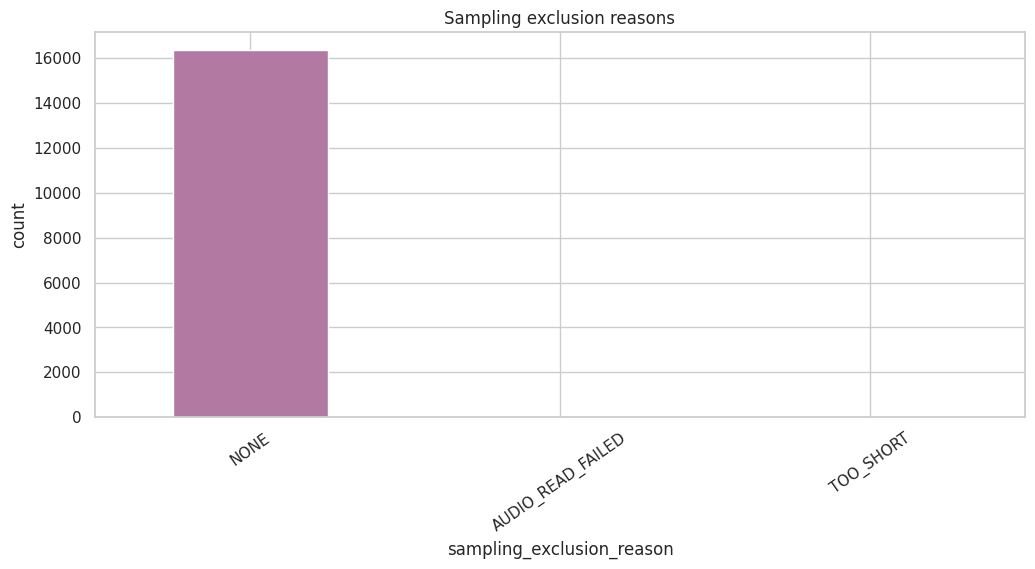

### Duration Summary

,count,mean,std,min,25%,50%,75%,max,missing_pct
actual_duration_s,16343.0,28.683911,4.955030,6.321633,29.988571,29.988571,30.014694,30.648889,0.07
duration_s,16343.0,28.745824,4.726818,7.000000,30.000000,30.000000,30.000000,31.000000,0.07


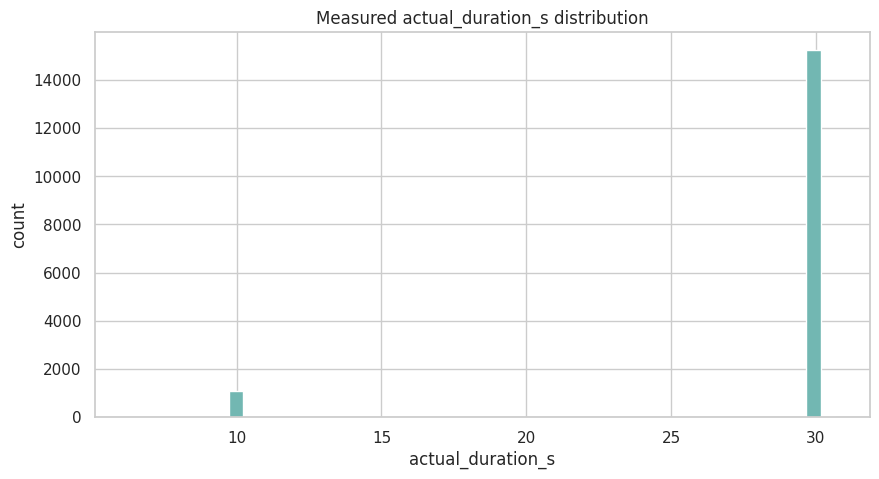

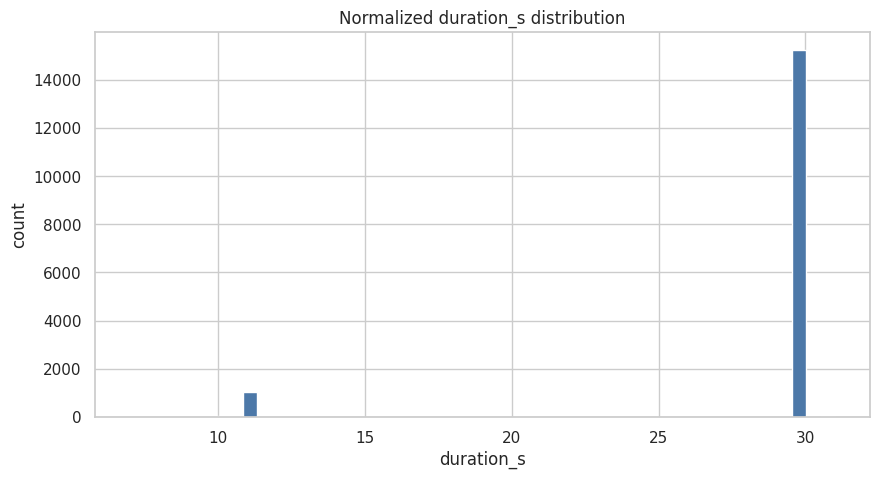

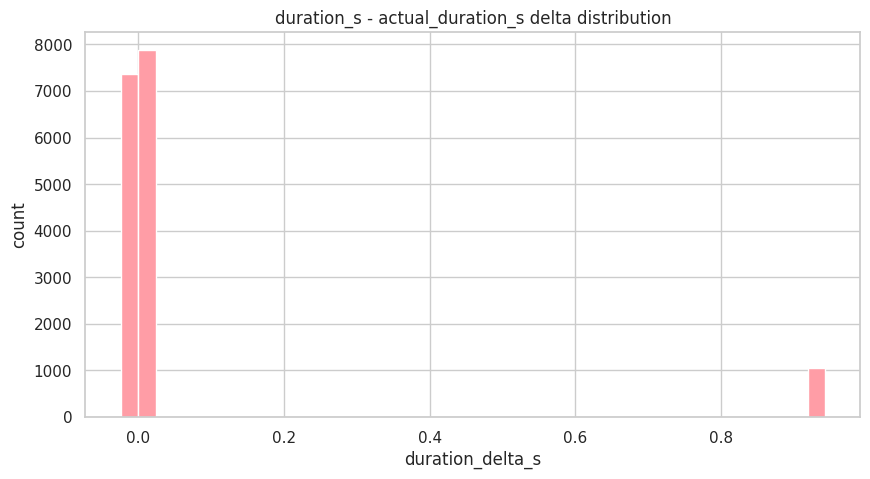

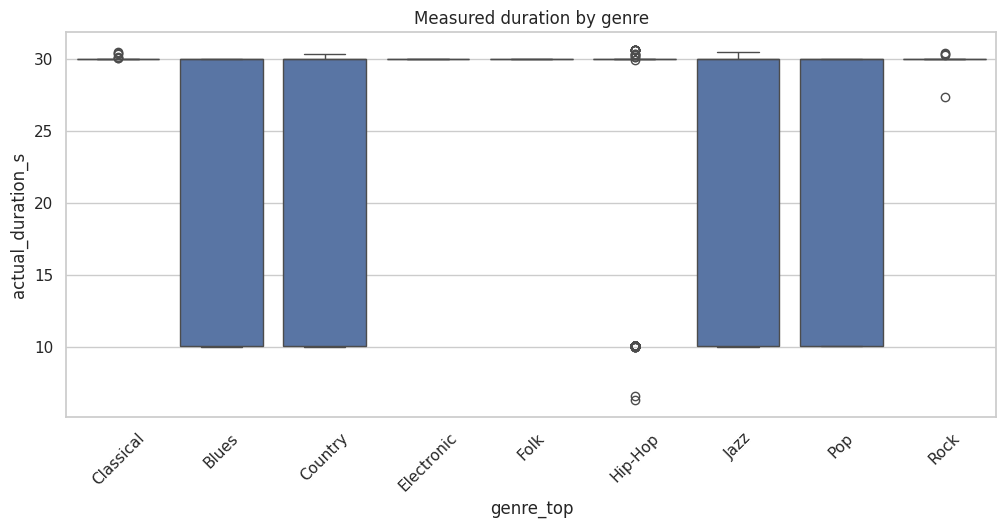

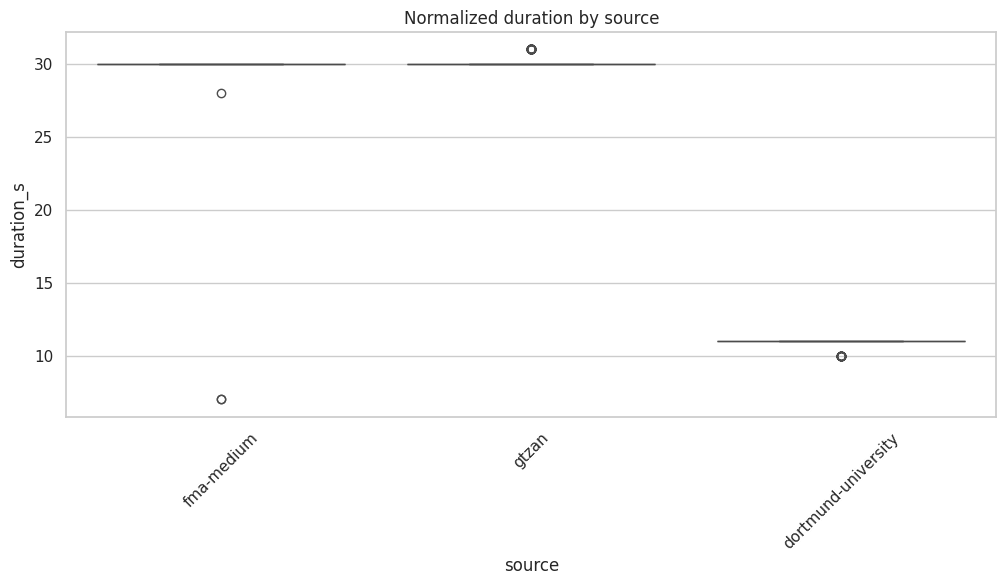

In [7]:
skip_reason_table = all_datasets_df.groupby(['source', 'reason_code']).size().unstack(fill_value=0)
display(Markdown("### Skipped Files by Source and Reason Code"))
display(skip_reason_table)
plot_heatmap(skip_reason_table, title='Skip reasons by source', fmt='.0f')

if 'sampling_exclusion_reason' in all_datasets_df.columns:
    sampling_exclusion_counts = all_datasets_df['sampling_exclusion_reason'].fillna('NONE').value_counts()
    display(Markdown("### sampling_exclusion_reason"))
    display(sampling_exclusion_counts.rename_axis('sampling_exclusion_reason').reset_index(name='count'))
    plot_bar(sampling_exclusion_counts, title='Sampling exclusion reasons', xlabel='sampling_exclusion_reason', rotation=35, figsize=(12, 5), color='#B279A2')

display(Markdown("### Duration Summary"))
duration_summary = all_datasets_df[['actual_duration_s', 'duration_s']].describe().T
duration_summary['missing_pct'] = all_datasets_df[['actual_duration_s', 'duration_s']].isna().mean().mul(100).round(2)
display(duration_summary)

duration_analysis_df = all_datasets_df.copy()
duration_analysis_df['duration_delta_s'] = duration_analysis_df['duration_s'] - duration_analysis_df['actual_duration_s']

plot_hist(duration_analysis_df['actual_duration_s'], title='Measured actual_duration_s distribution', bins=50)
plot_hist(duration_analysis_df['duration_s'], title='Normalized duration_s distribution', bins=50, color='#4C78A8')
plot_hist(duration_analysis_df['duration_delta_s'], title='duration_s - actual_duration_s delta distribution', bins=40, color='#FF9DA6')

plot_box(duration_analysis_df, value_col='actual_duration_s', category_col='genre_top', title='Measured duration by genre')
plot_box(duration_analysis_df, value_col='duration_s', category_col='source', title='Normalized duration by source')

## Duration Grouping and Notebook-Side Sample-Yield Analysis

This section computes a notebook-side analytic yield metric. It is intentionally separated from the script's emitted segment rows.

Notebook-side rule used here:

1. round measured duration upward to the next whole second
2. divide by `sample_length_sec`
3. also derive a whole-segment count with `floor(analytic_yield_ratio)` for comparison

This is an analysis metric, not a replacement for the script's current Stage 1 expansion contract.

,count,mean,std,min,25%,50%,75%,max
notebook_ceiled_duration_s,16341.0,29.161924,4.854389,10.0,30.0,30.0,31.0,31.0
notebook_yield_ratio,16341.0,2.916192,0.485439,1.0,3.0,3.0,3.1,3.1
notebook_full_segments,16341.0,2.868123,0.496302,1.0,3.0,3.0,3.0,3.0


### Files by Genre and Manual Duration Group

duration_group_manual,<= 10s,10-30s,30-60s
genre_top,,,
Blues,2.0,158.0,134.0
Classical,0.0,385.0,334.0
Country,4.0,317.0,179.0
Electronic,0.0,2995.0,2317.0
Folk,0.0,298.0,220.0
Hip-Hop,6.0,964.0,625.0
Jazz,12.0,526.0,264.0
Pop,0.0,226.0,176.0
Rock,0.0,3654.0,2545.0


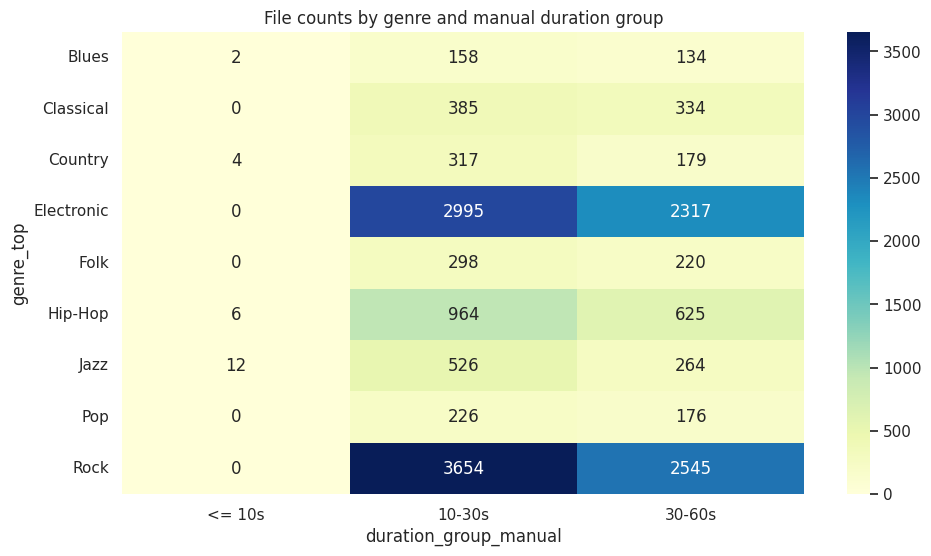

### Total Notebook-Side Full Segment Yield by Genre and Duration Group

duration_group_manual,<= 10s,10-30s,30-60s
genre_top,,,
Blues,2.0,238.0,402.0
Classical,0.0,1155.0,1002.0
Country,4.0,515.0,537.0
Electronic,0.0,8985.0,6951.0
Folk,0.0,894.0,660.0
Hip-Hop,6.0,2304.0,1875.0
Jazz,12.0,964.0,792.0
Pop,0.0,446.0,528.0
Rock,0.0,10961.0,7635.0


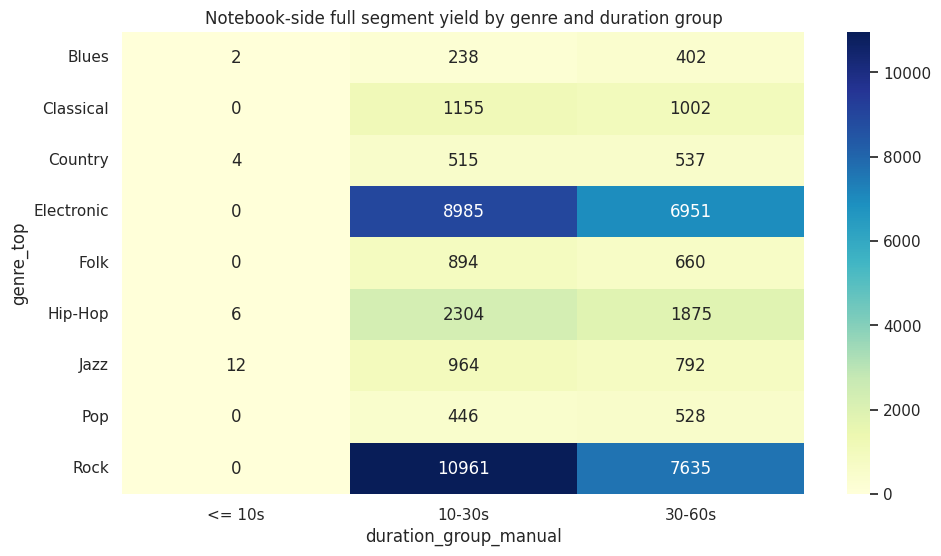

### Average Notebook-Side Full Segment Yield per File

duration_group_manual,<= 10s,10-30s,30-60s
genre_top,,,
Blues,1.0,1.51,3.0
Classical,0.0,3.00,3.0
Country,1.0,1.62,3.0
Electronic,0.0,3.00,3.0
Folk,0.0,3.00,3.0
Hip-Hop,1.0,2.39,3.0
Jazz,1.0,1.83,3.0
Pop,0.0,1.97,3.0
Rock,0.0,3.00,3.0


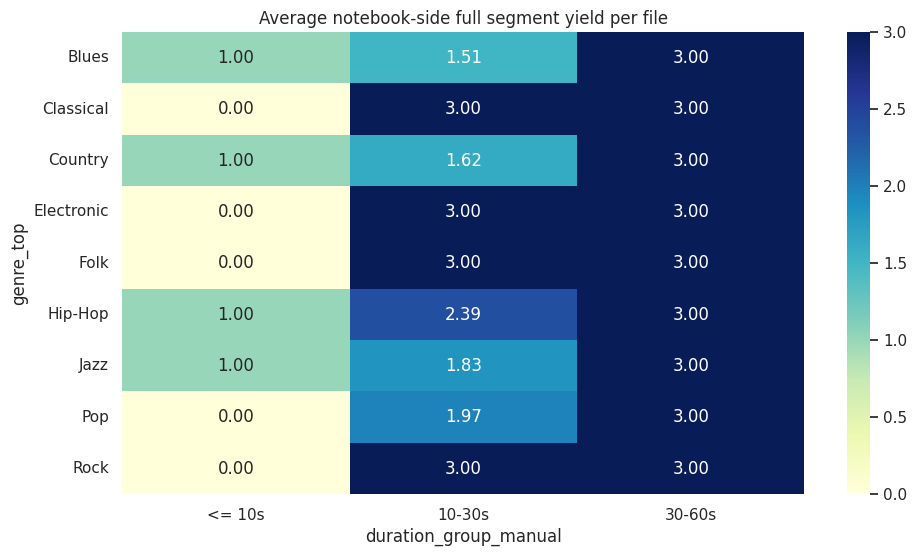

### Optional 1D K-means Duration Groups

,cluster,center_duration_s
0,1,10.0
1,2,11.0
2,3,30.0
3,4,31.0


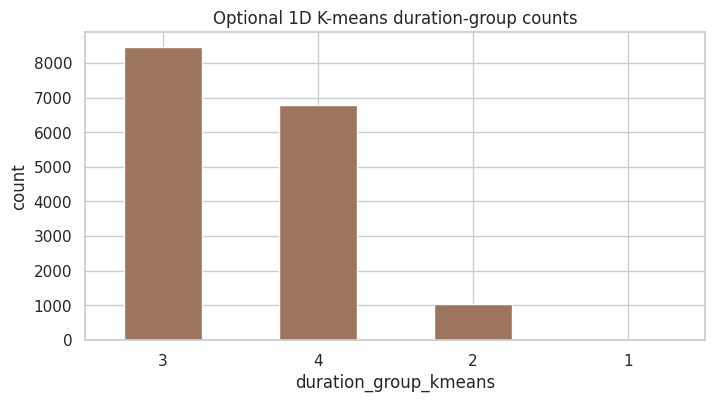

In [15]:
yield_df = all_datasets_df[all_datasets_df['reason_code'].eq('OK')].copy()
yield_df['artifact_id'] = yield_df['artifact_id'].astype(str)
yield_df['notebook_ceiled_duration_s'] = np.ceil(pd.to_numeric(yield_df['actual_duration_s'], errors='coerce')).astype('Int64')
yield_df['notebook_yield_ratio'] = pd.to_numeric(yield_df['notebook_ceiled_duration_s'], errors='coerce') / sample_length_sec
yield_df['notebook_full_segments'] = np.floor(yield_df['notebook_yield_ratio']).astype('Int64')

yield_df['duration_group_manual'] = pd.cut(
    pd.to_numeric(yield_df['actual_duration_s'], errors='coerce'),
    bins=[0, 10, 30, 60, 120, 300, np.inf],
    labels=[
        '<= 10s',
        '10-30s',
        '30-60s',
        '60-120s',
        '120-300s',
        '300s+'
    ],
    include_lowest=True,
)

kmeans_labels, kmeans_centers = maybe_duration_kmeans(yield_df['notebook_ceiled_duration_s'], n_clusters=4)
if kmeans_labels is not None:
    yield_df['duration_group_kmeans'] = kmeans_labels.astype('Int64')

yield_metric_summary = yield_df[['notebook_ceiled_duration_s', 'notebook_yield_ratio', 'notebook_full_segments']].describe().T
display(yield_metric_summary)

display(Markdown("### Files by Genre and Manual Duration Group"))
genre_duration_group_counts = pd.crosstab(yield_df['genre_top'], yield_df['duration_group_manual']).astype(float)
display(genre_duration_group_counts)
plot_heatmap(genre_duration_group_counts, title='File counts by genre and manual duration group', figsize=(11, 6), fmt='.0f')

display(Markdown("### Total Notebook-Side Full Segment Yield by Genre and Duration Group"))
yield_by_group = yield_df.pivot_table(
    index='genre_top',
    columns='duration_group_manual',
    values='notebook_full_segments',
    aggfunc='sum',
    fill_value=0,
).astype(float)
display(yield_by_group)
plot_heatmap(yield_by_group, title='Notebook-side full segment yield by genre and duration group', figsize=(11, 6), fmt='.0f')

display(Markdown("### Average Notebook-Side Full Segment Yield per File"))
avg_yield_by_group = yield_df.pivot_table(
    index='genre_top',
    columns='duration_group_manual',
    values='notebook_full_segments',
    aggfunc='mean',
    fill_value=0,
).astype(float).round(2)
display(avg_yield_by_group)
plot_heatmap(avg_yield_by_group, title='Average notebook-side full segment yield per file', figsize=(11, 6), fmt='.2f')

if kmeans_centers is not None:
    display(Markdown("### Optional 1D K-means Duration Groups"))
    display(kmeans_centers.round(2))
    kmeans_counts = yield_df['duration_group_kmeans'].value_counts().sort_index()
    plot_bar(kmeans_counts, title='Optional 1D K-means duration-group counts', xlabel='duration_group_kmeans', rotation=0, figsize=(8, 4), color='#9D755D')
else:
    print('scikit-learn not available or duration values do not support clustering; skipping optional K-means duration groups.')

## Actual Emitted Sample-Row Analysis

This section studies what Stage 1 actually emitted into `manifest_all_samples.parquet`. The focus is the emitted segment rows, not just theoretical supply.

,metric,value
0,total_emitted_segment_rows,46868.00
1,source_audio_items_with_emitted_segments,16341.00
2,mean_emitted_segments_per_audio,2.87
3,median_emitted_segments_per_audio,3.00


### Emitted Segment Rows by Genre

,genre_top,count,proportion_pct,imbalance_ratio_vs_max
0,Rock,18596,39.68,1.000
1,Electronic,15936,34.00,1.167
2,Hip-Hop,4185,8.93,4.443
3,Classical,2157,4.60,8.621
4,Jazz,1768,3.77,10.518
5,Folk,1554,3.32,11.967
6,Country,1056,2.25,17.610
7,Pop,974,2.08,19.092
8,Blues,642,1.37,28.966


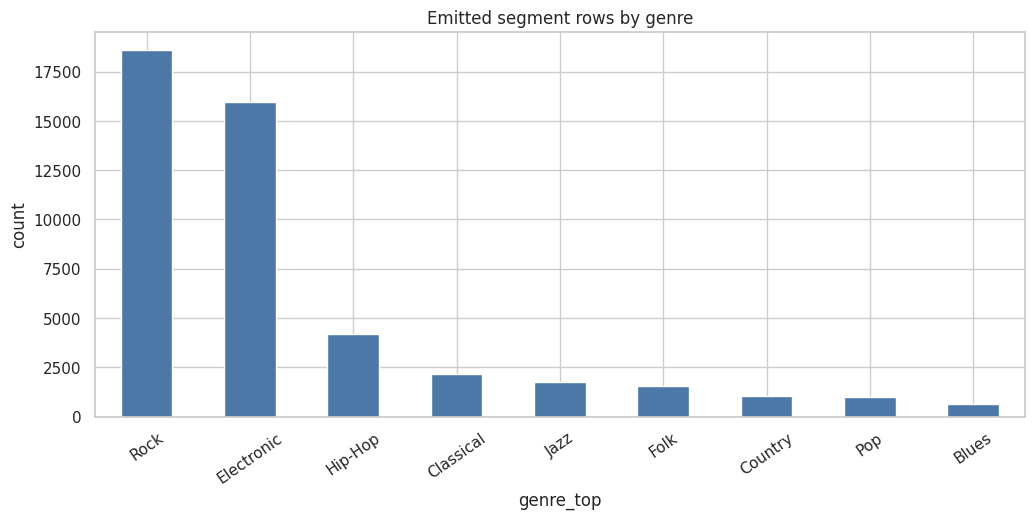

### Emitted Segment Rows by Source

,source,count
0,fma-medium,43694
1,gtzan,2097
2,dortmund-university,1077


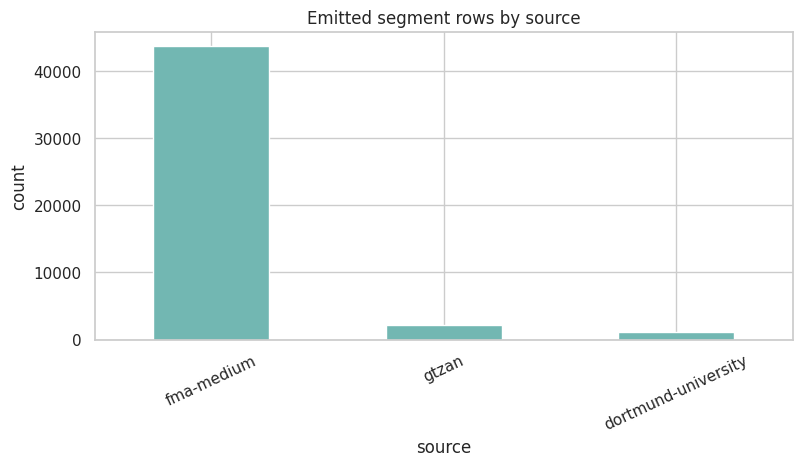

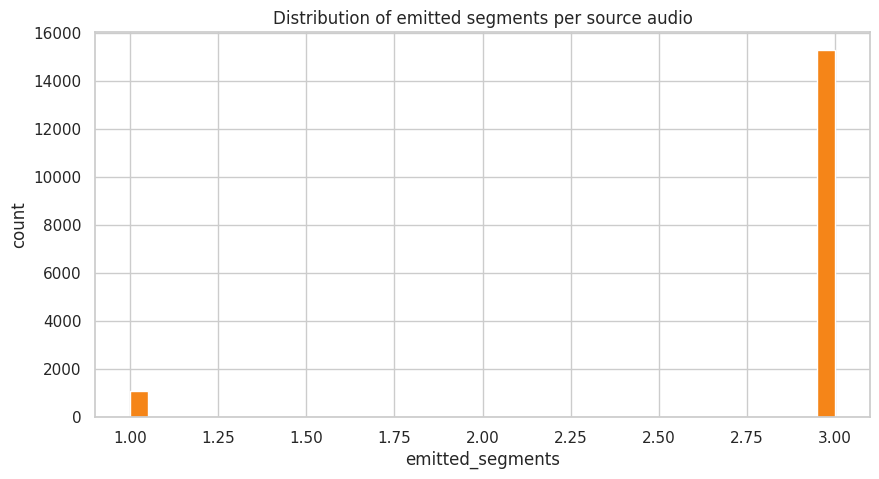

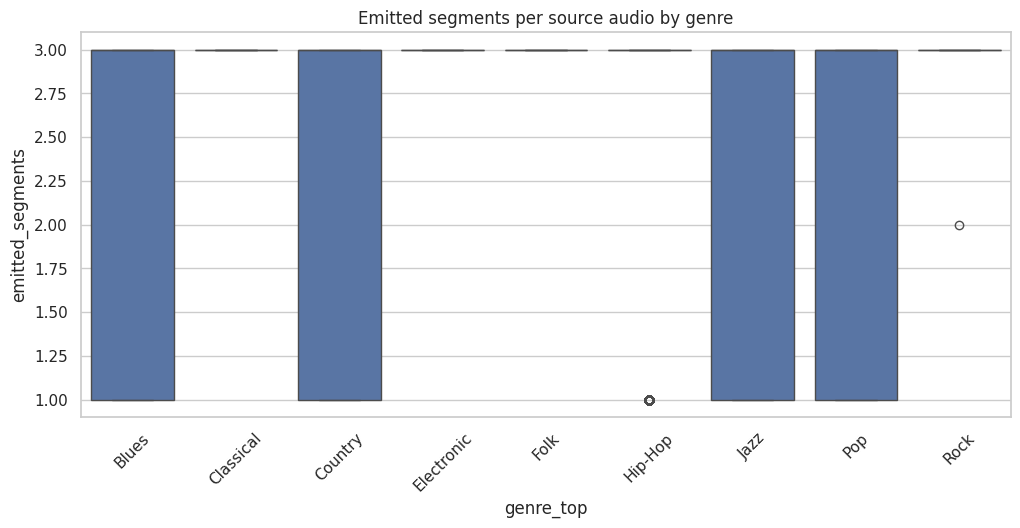

### Notebook-Side Yield vs Actual Emitted Segments

,count,mean,std,min,25%,50%,75%,max
notebook_full_segments,16343.0,2.867772,0.497285,0.0,3.0,3.0,3.0,3.0
emitted_segments,16343.0,2.867772,0.497285,0.0,3.0,3.0,3.0,3.0
yield_gap_emitted_minus_notebook,16343.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


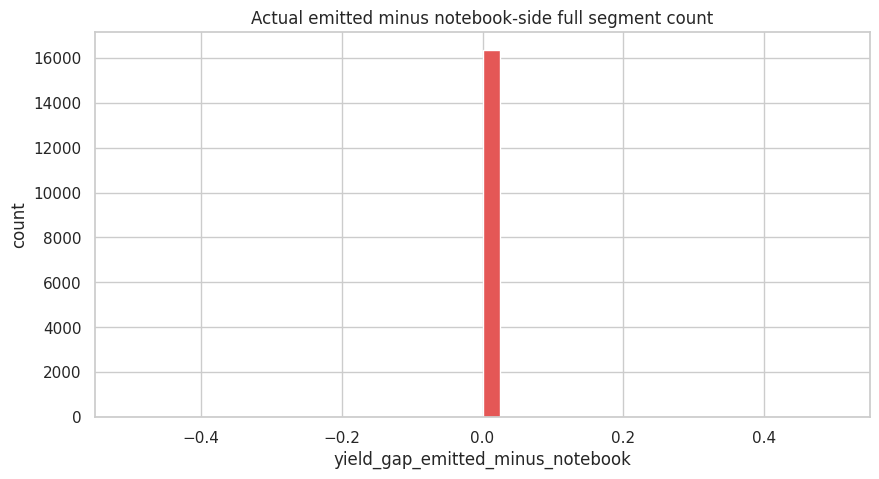

In [9]:
samples_audio_level = all_samples_df.copy()
samples_audio_level['artifact_id'] = samples_audio_level['sample_id'].map(artifact_id_from_sample_id)
samples_audio_level_summary = samples_audio_level.groupby('artifact_id').agg(
    source=('source', 'first'),
    genre_top=('genre_top', 'first'),
    duration_s=('duration_s', 'first'),
    actual_duration_s=('actual_duration_s', 'first'),
    total_segments_from_audio=('total_segments_from_audio', 'first'),
    emitted_segments=('sample_id', 'size'),
).reset_index()

comparison_df = yield_df.merge(
    samples_audio_level_summary[['artifact_id', 'emitted_segments', 'total_segments_from_audio']],
    on='artifact_id',
    how='left',
)
comparison_df['emitted_segments'] = comparison_df['emitted_segments'].fillna(0).astype('Int64')
comparison_df['yield_gap_emitted_minus_notebook'] = comparison_df['emitted_segments'] - comparison_df['notebook_full_segments']

sample_summary = pd.DataFrame([
    {"metric": "total_emitted_segment_rows", "value": len(all_samples_df)},
    {"metric": "source_audio_items_with_emitted_segments", "value": len(samples_audio_level_summary)},
    {"metric": "mean_emitted_segments_per_audio", "value": round(samples_audio_level_summary['emitted_segments'].mean(), 2)},
    {"metric": "median_emitted_segments_per_audio", "value": round(samples_audio_level_summary['emitted_segments'].median(), 2)},
])
display(sample_summary)

segments_by_genre = all_samples_df['genre_top'].value_counts()
display(Markdown("### Emitted Segment Rows by Genre"))
display(imbalance_table(all_samples_df['genre_top']))
plot_bar(segments_by_genre, title='Emitted segment rows by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#4C78A8')

segments_by_source = all_samples_df['source'].value_counts()
display(Markdown("### Emitted Segment Rows by Source"))
display(segments_by_source.rename_axis('source').reset_index(name='count'))
plot_bar(segments_by_source, title='Emitted segment rows by source', xlabel='source', rotation=25, figsize=(9, 4), color='#72B7B2')

plot_hist(samples_audio_level_summary['emitted_segments'], title='Distribution of emitted segments per source audio', bins=40, color='#F58518')
plot_box(samples_audio_level_summary, value_col='emitted_segments', category_col='genre_top', title='Emitted segments per source audio by genre')

comparison_summary = comparison_df[['notebook_full_segments', 'emitted_segments', 'yield_gap_emitted_minus_notebook']].describe().T
display(Markdown("### Notebook-Side Yield vs Actual Emitted Segments"))
display(comparison_summary)
plot_hist(comparison_df['yield_gap_emitted_minus_notebook'], title='Actual emitted minus notebook-side full segment count', bins=40, color='#E45756')

## Final Split Analysis and Leakage-Safety Validation

Stage 2 assigns final splits at the source-audio level by grouping segment ids after removing the `:segNNNN` suffix. This section checks split balance and verifies that no source-audio group leaks across multiple splits.

### Final Split Counts

,final_split,count
0,training,8380
1,validation,1055
2,test,1046


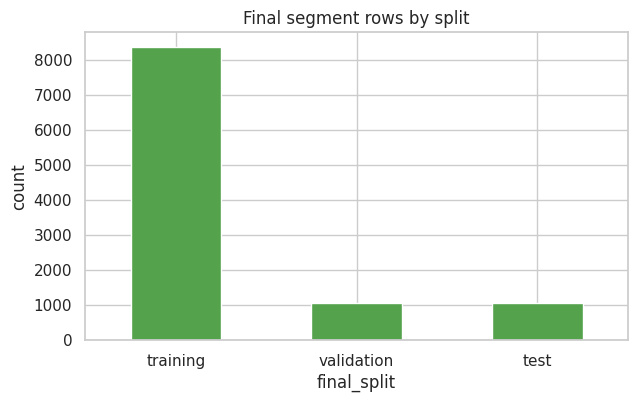

### Final Counts by Genre and Split

final_split,test,training,validation
genre_top,,,
Blues,65,512,65
Classical,129,1041,132
Country,106,845,105
Electronic,129,1041,132
Folk,129,1041,132
Hip-Hop,131,1039,130
Jazz,130,1040,131
Pop,98,780,96
Rock,129,1041,132


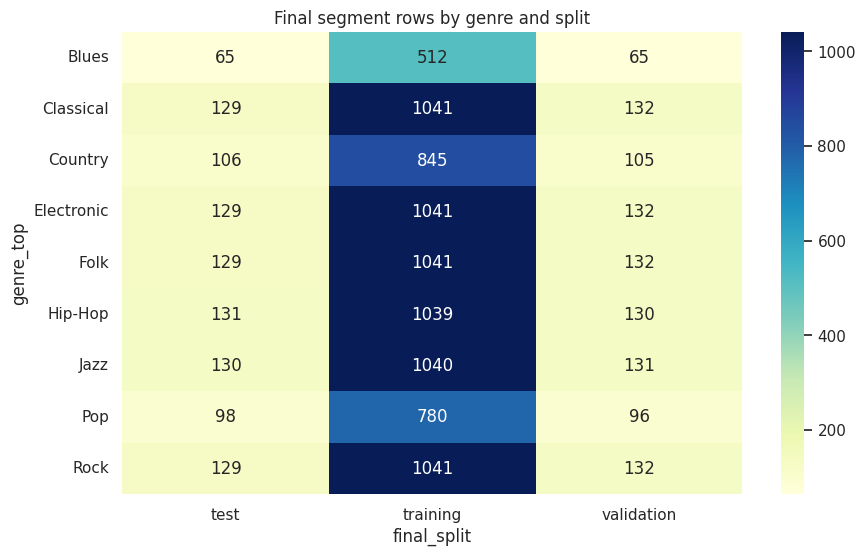

### Within-Genre Split Percentages

final_split,test,training,validation
genre_top,,,
Blues,10.12,79.75,10.12
Classical,9.91,79.95,10.14
Country,10.04,80.02,9.94
Electronic,9.91,79.95,10.14
Folk,9.91,79.95,10.14
Hip-Hop,10.08,79.92,10.00
Jazz,9.99,79.94,10.07
Pop,10.06,80.08,9.86
Rock,9.91,79.95,10.14


### Leakage-Safety Check

,metric,value
0,artifacts_in_multiple_final_splits,0


Leakage check passed: no source-audio artifact appears in more than one final split.


In [ ]:
final_split_counts = final_samples_df['final_split'].value_counts()
display(Markdown("### Final Split Counts"))
display(final_split_counts.rename_axis('final_split').reset_index(name='count'))
plot_bar(final_split_counts, title='Final segment rows by split', xlabel='final_split', rotation=0, figsize=(7, 4), color='#54A24B')

genre_split_table = pd.crosstab(final_samples_df['genre_top'], final_samples_df['final_split'])
display(Markdown("### Final Counts by Genre and Split"))
display(genre_split_table)
plot_heatmap(genre_split_table, title='Final segment rows by genre and split', figsize=(10, 6), fmt='.0f')

genre_split_pct = genre_split_table.div(genre_split_table.sum(axis=1), axis=0).mul(100).round(2)
display(Markdown("### Within-Genre Split Percentages"))
display(genre_split_pct)

final_samples_source_view = final_samples_df.copy()
final_samples_source_view['source_family'] = np.where(
    final_samples_source_view['source'].astype(str).str.casefold().str.startswith('fma'),
    'fma',
    'additional_datasets',
)
additional_ratio_target_pct = round(
    float(sampling_settings.get('additional_samples_contribution_ratio_expected_each_genre', 0.0)) * 100,
    2,
)

display(Markdown("### Additional-Dataset Contribution in Final Manifest"))
overall_source_counts = (
    final_samples_source_view['source_family']
    .value_counts()
    .reindex(['fma', 'additional_datasets'], fill_value=0)
)
overall_additional_share_pct = round(
    overall_source_counts.get('additional_datasets', 0) / max(len(final_samples_source_view), 1) * 100,
    2,
)
display(
    pd.DataFrame(
        [
            {'metric': 'target_additional_contribution_pct', 'value': additional_ratio_target_pct},
            {'metric': 'actual_additional_contribution_pct', 'value': overall_additional_share_pct},
            {'metric': 'actual_fma_contribution_pct', 'value': round(100 - overall_additional_share_pct, 2)},
        ]
    )
)

genre_source_table = pd.crosstab(
    final_samples_source_view['genre_top'],
    final_samples_source_view['source_family'],
).reindex(columns=['fma', 'additional_datasets'], fill_value=0)
genre_source_pct = genre_source_table.div(genre_source_table.sum(axis=1), axis=0).mul(100).round(2)
genre_source_pct['target_additional_pct'] = additional_ratio_target_pct
genre_source_pct['gap_vs_target_pct'] = (
    genre_source_pct['additional_datasets'] - genre_source_pct['target_additional_pct']
).round(2)
display(Markdown("### Additional Contribution by Genre"))
display(genre_source_table)
display(genre_source_pct)
plot_heatmap(
    genre_source_pct[['additional_datasets', 'target_additional_pct', 'gap_vs_target_pct']].astype(float),
    title='Final additional contribution percentage by genre',
    figsize=(8, 6),
    fmt='.2f',
)

split_order = ['training', 'validation', 'test']
additional_by_genre_split = (
    final_samples_source_view[final_samples_source_view['source_family'] == 'additional_datasets']
    .groupby(['genre_top', 'final_split'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=split_order, fill_value=0)
)
genre_split_totals = (
    final_samples_source_view.groupby(['genre_top', 'final_split'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=split_order, fill_value=0)
)
additional_ratio_by_genre_split = (
    additional_by_genre_split.div(genre_split_totals.replace(0, np.nan)).mul(100).round(2).fillna(0.0)
)
display(Markdown("### Additional Contribution by Genre and Split"))
display(additional_by_genre_split)
display(additional_ratio_by_genre_split)
plot_heatmap(
    additional_ratio_by_genre_split.astype(float),
    title='Additional contribution percentage by genre and final split',
    figsize=(9, 6),
    fmt='.2f',
)

final_samples_with_artifact = final_samples_df.copy()
final_samples_with_artifact['artifact_id'] = final_samples_with_artifact['sample_id'].map(artifact_id_from_sample_id)
artifact_split_counts = final_samples_with_artifact.groupby('artifact_id')['final_split'].nunique()
leakage_artifacts = artifact_split_counts[artifact_split_counts > 1]
leakage_count = int(leakage_artifacts.shape[0])

display(Markdown("### Leakage-Safety Check"))
display(pd.DataFrame([{"metric": "artifacts_in_multiple_final_splits", "value": leakage_count}]))
if leakage_count == 0:
    print('Leakage check passed: no source-audio artifact appears in more than one final split.')
else:
    display(leakage_artifacts.rename('num_splits').reset_index())
    raise AssertionError('Leakage detected: at least one artifact appears in multiple final splits.')

## Class Balance Evolution Across Stages

This section tracks how the genre distribution changes from file-level discovery to segment-level expansion to final training-ready segments.

,file_level_OK,all_samples,final_samples
genre_top,,,
Rock,6199,18596,1302
Electronic,5312,15936,1302
Hip-Hop,1595,4185,1300
Jazz,802,1768,1301
Classical,719,2157,1302
Folk,518,1554,1302
Country,500,1056,1056
Pop,402,974,974
Blues,294,642,642


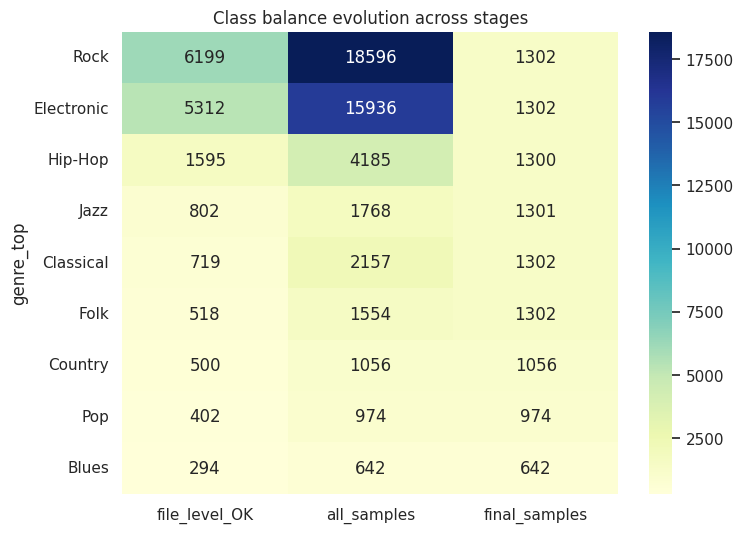

### Stage-wise Genre Percentages

,file_level_OK,all_samples,final_samples
genre_top,,,
Rock,37.94,39.68,12.42
Electronic,32.51,34.00,12.42
Hip-Hop,9.76,8.93,12.40
Jazz,4.91,3.77,12.41
Classical,4.40,4.60,12.42
Folk,3.17,3.32,12.42
Country,3.06,2.25,10.08
Pop,2.46,2.08,9.29
Blues,1.80,1.37,6.13


In [13]:
usable_file_stage = all_datasets_df[all_datasets_df['reason_code'] == 'OK'].copy()
balance_evolution = pd.concat([
    usable_file_stage['genre_top'].value_counts().rename('file_level_OK'),
    all_samples_df['genre_top'].value_counts().rename('all_samples'),
    final_samples_df['genre_top'].value_counts().rename('final_samples'),
], axis=1).fillna(0).astype(int)

display(balance_evolution)
plot_heatmap(balance_evolution, title='Class balance evolution across stages', figsize=(8, 6), fmt='.0f')

balance_evolution_pct = balance_evolution.div(balance_evolution.sum(axis=0), axis=1).mul(100).round(2)
display(Markdown("### Stage-wise Genre Percentages"))
display(balance_evolution_pct)

In [ ]:
dominant_file_genre = usable_file_stage['genre_top'].value_counts().idxmax() if not usable_file_stage.empty else 'N/A'
smallest_final_genre = final_samples_df['genre_top'].value_counts().idxmin() if not final_samples_df.empty else 'N/A'
top_reason_code = all_datasets_df['reason_code'].value_counts().idxmax() if not all_datasets_df.empty else 'N/A'
largest_duration_group = yield_df['duration_group_manual'].value_counts().idxmax() if not yield_df.empty else 'N/A'
mean_emitted_segments = round(samples_audio_level_summary['emitted_segments'].mean(), 2) if not samples_audio_level_summary.empty else 0
training_share_pct = round(final_split_counts.get('training', 0) / max(len(final_samples_df), 1) * 100, 2)
mean_genre_additional_gap_pct = round(genre_source_pct['gap_vs_target_pct'].abs().mean(), 2) if 'genre_source_pct' in globals() and not genre_source_pct.empty else 0

summary_markdown = f"""
## Key Findings and Training-Readiness Summary

1. The file-level usable dataset is dominated by **{dominant_file_genre}** when counting `reason_code == 'OK'` rows.
2. The most frequent file-level reason code is **{top_reason_code}**, which is the first indicator of what shapes dataset usability.
3. The largest notebook-side manual duration group is **{largest_duration_group}**, meaning that group contributes the largest share of potential sample supply.
4. The emitted sample manifest contains an average of **{mean_emitted_segments}** segments per source audio among rows that actually produced segments.
5. The final manifest assigns **{training_share_pct}%** of selected segments to the training split.
6. The final manifest targets **{additional_ratio_target_pct}%** additional-dataset contribution and currently achieves **{overall_additional_share_pct}%** overall.
7. The mean absolute per-genre gap versus the configured additional-dataset target is **{mean_genre_additional_gap_pct} percentage points**.
8. The least represented final genre is **{smallest_final_genre}**. This is a useful place to inspect downstream class balance risk.
9. Leakage validation passed with **{leakage_count}** source-audio artifacts assigned to more than one final split.

Overall readiness interpretation:

- the manifest pipeline is auditable because file-level discovery, skip reasons, segment expansion, final split assignment, and final-source contribution are all visible
- the separation between `actual_duration_s` and `duration_s` is observable and measurable
- duration shape materially influences sample yield
- the additional-dataset contribution target can be checked directly at overall, per-genre, and per-split levels
- final split safety can be checked directly from `sample_id` grouping
- this notebook provides a training-readiness audit before feature extraction and CNN training
"""

display(Markdown(summary_markdown))


## Key Findings and Training-Readiness Summary

1. The file-level usable dataset is dominated by **Rock** when counting `reason_code == 'OK'` rows.
2. The most frequent file-level reason code is **OK**, which is the first indicator of what shapes dataset usability.
3. The largest notebook-side manual duration group is **10-30s**, meaning that group contributes the largest share of potential sample supply.
4. The emitted sample manifest contains an average of **2.87** segments per source audio among rows that actually produced segments.
5. The final manifest assigns **79.95%** of selected segments to the training split.
6. The least represented final genre is **Blues**. This is a useful place to inspect downstream class balance risk.
7. Leakage validation passed with **0** source-audio artifacts assigned to more than one final split.

Overall readiness interpretation:

- the manifest pipeline is auditable because file-level discovery, skip reasons, segment expansion, and final split assignment are all visible
- the separation between `actual_duration_s` and `duration_s` is observable and measurable
- duration shape materially influences sample yield
- final split safety can be checked directly from `sample_id` grouping
- this notebook provides a training-readiness audit before feature extraction and CNN training
